In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

sns.set_theme(style="darkgrid")



In [2]:

# 1. The Kaggle Dataset ("Position Salaries")
# We use io.StringIO to simulate reading a CSV file directly in the code
kaggle_data = """Position,Level,Salary
Business Analyst,1,45000
Junior Consultant,2,50000
Senior Consultant,3,60000
Manager,4,80000
Country Manager,5,110000
Region Manager,6,150000
Partner,7,200000
Senior Partner,8,300000
C-level,9,500000
CEO,10,1000000"""


In [3]:

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(io.StringIO(kaggle_data))

print("Dataset Preview:")
print(df)
print("-" * 30)



Dataset Preview:
            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000
------------------------------


In [4]:
# Extracting Features (X) and Target (y)
# X is the 'Level' (independent variable), y is the 'Salary' (dependent variable)
X = df.iloc[:, 1:2].values  # Using .iloc ensures X is a 2D array, which scikit-learn requires
y = df.iloc[:, 2].values

In [5]:
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [7]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [8]:


# 2. Fit standard Linear Regression (For comparison)
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# 3. Fit Polynomial Regression (Degree 4)
# We transform the data to the 4th degree (x, x^2, x^3, x^4) for a much tighter curve
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


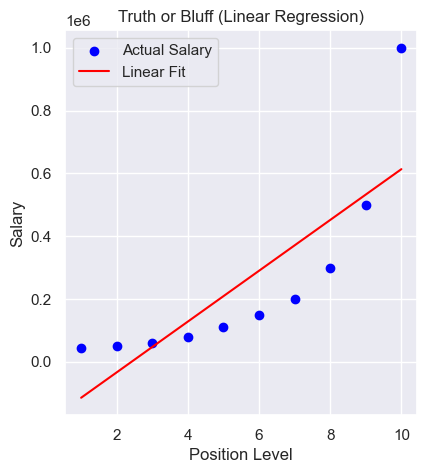

In [9]:
# 4. Visualizing the Results

plt.figure(figsize=(10, 5))

# Plot 1: Standard Linear Regression (Underfitting)
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', label='Actual Salary')
plt.plot(X, lin_reg.predict(X), color='red', label='Linear Fit')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()


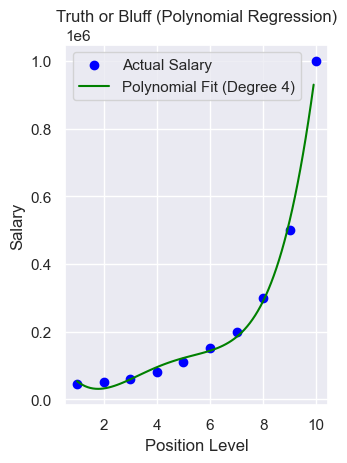

In [15]:

# Plot 2: Polynomial Regression (Perfect Fit)
# Generate a smoother curve by creating a dense grid of X values
X_grid = np.arange(X.flatten().min(), X.flatten().max(), 0.1).reshape(-1, 1)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', label='Actual Salary')
plt.plot(X_grid, poly_reg.predict(poly_features.fit_transform(X_grid)), color='green', label='Polynomial Fit (Degree 4)')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:

# 5. Making a Prediction
# Let's say we want to predict the salary for someone at level 6.5
level_to_predict = [[2]]

linear_pred = lin_reg.predict(level_to_predict)[0]
poly_pred = poly_reg.predict(poly_features.fit_transform(level_to_predict))[0]

print(f"Prediction for Level 6.5 (Linear Regression): ${linear_pred:,.2f} (Inaccurate)")
print(f"Prediction for Level 6.5 (Polynomial Regression): ${poly_pred:,.2f} (Accurate)")

Prediction for Level 6.5 (Linear Regression): $-33,575.76 (Inaccurate)
Prediction for Level 6.5 (Polynomial Regression): $31,759.91 (Accurate)
